# Homework 6 Code File

In [2]:
import arviz as az
import pandas as pd
import numpy as np
import pymc as pm
from pymc.math import exp
import matplotlib.pyplot as plt
import pytensor.tensor as pt
from pytensor.tensor.variable import TensorVariable
from itertools import combinations
import warnings
warnings.filterwarnings("ignore")
rng = np.random.default_rng(6420)

In [3]:
# Load trace from nc file
trace_bcf = az.from_netcdf(f"ISYE6420/Project/bcf_joint_trace_with_intercept_ZINB.nc")
az.summary(trace_bcf, var_names=["kappa", "psi", "intercept"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
kappa,0.977,0.215,0.630,1.384,0.013,0.007,205.0,612.0,1.03
psi,0.685,0.064,0.562,0.797,0.005,0.002,145.0,389.0,1.03
intercept,-2.212,0.325,-2.800,-1.614,0.117,0.058,8.0,18.0,1.52


## Question 1

In [ ]:
mice_data = pd.read_csv("data/mice.csv")
mice_data.head()

,weeks,censored,group
0,12.0,0.0,Irradiated Control
1,1.0,0.0,Irradiated Control
2,21.0,0.0,Irradiated Control
3,25.0,0.0,Irradiated Control
4,11.0,0.0,Irradiated Control


In [ ]:
mice_data[mice_data["censored"] != 0].head()

,weeks,censored,group
17,NaN,40.0,Irradiated Control
25,NaN,40.0,Vehicle Control
26,NaN,40.0,Vehicle Control
30,NaN,40.0,Vehicle Control
32,NaN,40.0,Vehicle Control


In [ ]:
y = mice_data["weeks"].copy()
censored = mice_data["censored"].copy()
y[np.isnan(y)] = censored[np.isnan(y)]
censored[censored == 0] = np.inf

# convert group labels to integer indices
group_idx = mice_data["group"].astype("category").cat.codes.values
group_names = mice_data["group"].astype("category").cat.categories.values

In [ ]:
def pairwise_contrasts_v2(tensor: TensorVariable) -> TensorVariable:
    """Returns the array of pair-wise differences"""
    differences = tensor[:, None] - tensor
    upper_tri = pt.triu_indices_from(differences, k=1)
    return differences[upper_tri]

contrast_var = "contrast_median_survival"
contrast_labels = [
    f"{c1} - {c2}" for c1, c2 in combinations(group_names, 2)
]

In [ ]:
# Model Weibull survival data with right censoring (as censored poinsts are indicated by missing values in weeks variables, and upper limit in censored variable)
with pm.Model(coords={"group": group_names, "contrast_labels": contrast_labels}) as model:
    # Associate data with the model
    pm.Data("group_idx", group_idx)
    pm.Data("y", y)  # Number of weeks until death or censoring

    alpha = pm.Gamma("alpha", alpha=0.001, beta=0.001)
    beta = pm.Normal("beta", mu=0, sigma=1000, shape=4, dims="group")
    # Scale parameter for each group
    beta_prime = pm.Deterministic("beta_prime", 1/(pm.math.exp(beta[group_idx])))

    # Define the likelihood for uncensored data
    obs_latent = pm.Weibull.dist(alpha=alpha, beta=beta_prime)
    # Define the likelihood for censored data
    obs_censored = pm.Censored(
        "censored", obs_latent, lower=None, upper=censored, observed=y
        )

    # Compute median survival times for each group
    median_survival = pm.Deterministic(
        "median_survival", pm.math.exp(-beta) * np.log(2) ** (1 / alpha), dims="group"
        )
    S = pm.Deterministic("survival", pm.math.exp(-((obs_censored / beta_prime) ** alpha)))
    pdf = (
        (alpha / beta_prime) * ((obs_censored / beta_prime) ** (alpha - 1)) * pm.math.exp(-((obs_censored / beta_prime) ** alpha))
    )
    hazard = pm.Deterministic("hazard", pdf / S)

    # Calculate contrasts between groups
    pm.Deterministic(
        contrast_var, pairwise_contrasts_v2(median_survival), dims="contrast_labels"
    )

    # Predict survival at t=30 weeks for each group
    t_pred = pm.Data("t", 30)
    pm.Deterministic("survival_at_30", pm.math.exp(-((t_pred * pm.math.exp(beta)) ** alpha)), dims="group")
    
    # Sampling
    trace_1 = pm.sample(10000, tune=2000, nuts_sampler="nutpie", random_seed=rng)

az.summary(trace_1, var_names=["median_survival"], round_to=3, hdi_prob=0.95)     

Progress,Draws,Divergences,Step Size,Gradients/Draw
,12000,0,0.99,3
,12000,0,0.94,7
,12000,0,0.85,7
,12000,0,0.80,3


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
median_survival[Irradiated Control],23.542,2.062,19.614,27.699,0.010,0.010,45026.033,30848.696,1.0
median_survival[Positive Control],21.232,1.924,17.554,25.097,0.009,0.010,48400.270,31579.933,1.0
median_survival[Test Substance],25.929,2.450,21.284,30.847,0.011,0.013,46662.100,31220.031,1.0
median_survival[Vehicle Control],35.097,3.658,28.313,42.429,0.018,0.022,47024.722,29585.614,1.0


Text(0.5, 1.0, 'Median Survival Times with 95% Credible Intervals')

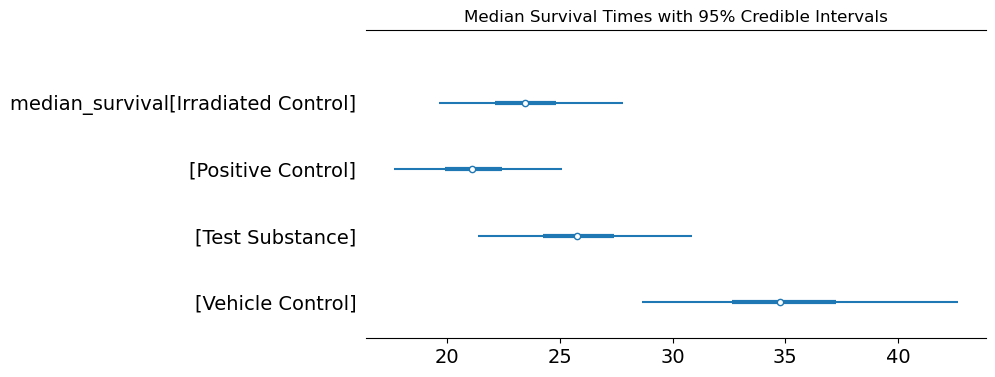

In [166]:
# Plot median survival times with 95% credible intervals
ax = az.plot_forest(
    trace_1,
    var_names=["median_survival"],
    combined=True,
    hdi_prob=0.95,
    figsize=(8, 4),
)
ax[0].set_title("Median Survival Times with 95% Credible Intervals")

In [167]:
az.summary(trace_1, round_to=3, hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_log__,1.034,0.107,0.819,1.238,0.001,0.000,37093.063,30118.756,1.0
beta[Irradiated Control],-3.286,0.085,-3.454,-3.121,0.000,0.000,46083.933,31711.294,1.0
beta[Positive Control],-3.183,0.089,-3.358,-3.013,0.000,0.000,49531.101,30549.363,1.0
beta[Test Substance],-3.381,0.091,-3.566,-3.207,0.000,0.000,47964.667,31726.409,1.0
beta[Vehicle Control],-3.684,0.102,-3.888,-3.488,0.000,0.001,44305.436,28662.465,1.0
...,...,...,...,...,...,...,...,...,...
contrast_median_survival[Test Substance - Vehicle Control],-9.204,4.338,-17.999,-0.853,0.021,0.024,43148.166,29776.236,1.0
survival_at_30[Irradiated Control],0.255,0.079,0.107,0.409,0.000,0.000,49452.384,31677.199,1.0
survival_at_30[Positive Control],0.164,0.073,0.039,0.309,0.000,0.000,49625.556,30262.918,1.0
survival_at_30[Test Substance],0.348,0.090,0.179,0.528,0.000,0.000,49949.348,32840.547,1.0


In [168]:
# Summarise and plot contrasts
contrast_summary = az.summary(trace_1, var_names="contrast_median_survival", round_to=3, hdi_prob=0.95)
contrast_summary


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
contrast_median_survival[Irradiated Control - Positive Control],2.297,2.750,-3.150,7.780,0.013,0.014,47070.424,31331.011,1.0
contrast_median_survival[Irradiated Control - Test Substance],-2.373,3.107,-8.641,3.714,0.014,0.016,48196.406,30887.578,1.0
contrast_median_survival[Irradiated Control - Vehicle Control],-11.576,4.156,-19.858,-3.557,0.021,0.023,42168.385,28767.778,1.0
contrast_median_survival[Positive Control - Test Substance],-4.669,3.064,-10.966,1.144,0.014,0.015,48023.548,32285.093,1.0
contrast_median_survival[Positive Control - Vehicle Control],-13.873,4.090,-22.144,-6.047,0.020,0.023,43815.725,30264.665,1.0
contrast_median_survival[Test Substance - Vehicle Control],-9.204,4.338,-17.999,-0.853,0.021,0.024,43148.166,29776.236,1.0


Text(0.5, 0, 'Difference in Beta Coefficients')

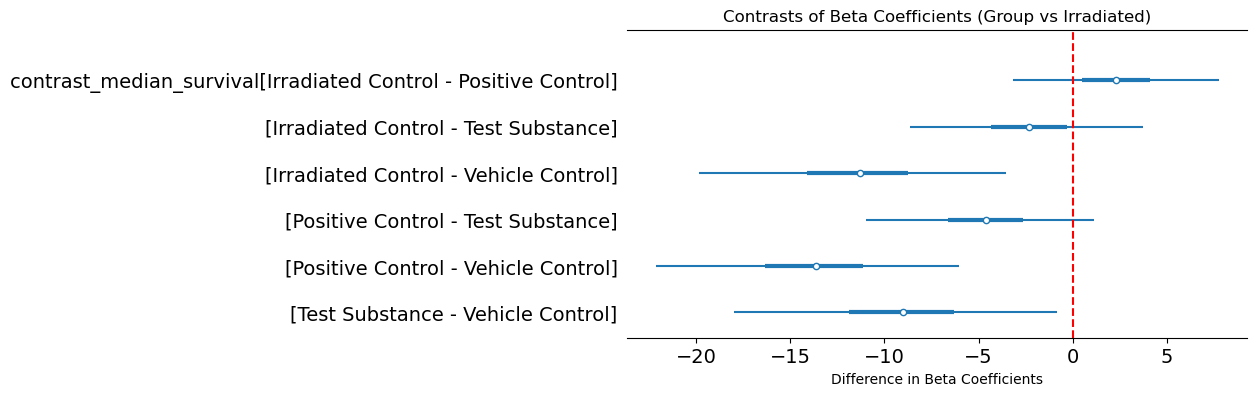

In [169]:
az.plot_forest(
    trace_1,
    var_names="contrast_median_survival",
    combined=True,
    hdi_prob=0.95,
    figsize=(8, 4),
)
plt.title("Contrasts of Beta Coefficients (Group vs Irradiated)")
# Add vertical line at zero for reference
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Difference in Beta Coefficients")

In [170]:
# Estimate survival for mouse when weeks, t=30 for each group
survival_t_30 = az.summary(trace_1, var_names=["survival_at_30"], round_to=3, hdi_prob=0.95)
survival_t_30

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
survival_at_30[Irradiated Control],0.255,0.079,0.107,0.409,0.0,0.0,49452.384,31677.199,1.0
survival_at_30[Positive Control],0.164,0.073,0.039,0.309,0.0,0.0,49625.556,30262.918,1.0
survival_at_30[Test Substance],0.348,0.090,0.179,0.528,0.0,0.0,49949.348,32840.547,1.0
survival_at_30[Vehicle Control],0.631,0.081,0.469,0.783,0.0,0.0,49115.020,30744.137,1.0


Text(0.5, 1.0, 'Predicted Survival Probability at t=30 Weeks with 95% Credible Intervals')

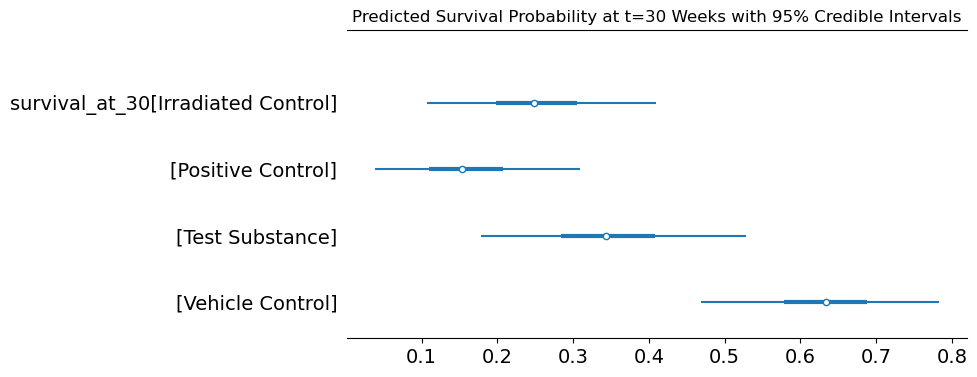

In [175]:
# plot forest plot for survival at t=30 weeks
az.plot_forest(
    trace_1,
    var_names=["survival_at_30"],
    combined=True,
    hdi_prob=0.95,
    figsize=(8, 4),
)
plt.title("Predicted Survival Probability at t=30 Weeks with 95% Credible Intervals")

## Question 2

In [4]:
hockpend_data = pd.read_csv("data/hockpend.csv")
hockpend_data.head()

,x1,x2,x3,y
0,12.980,0.317,9.998,57.702
1,14.295,2.028,6.776,59.295
2,15.531,5.305,2.947,55.166
3,15.133,4.738,4.201,55.767
4,15.342,7.038,2.053,51.722


In [5]:
y = hockpend_data["y"].to_numpy(copy=True)
X = hockpend_data[["x1", "x2", "x3"]].to_numpy(copy=True)
n, p = X.shape
print(f"Number of observations: {n}, Number of predictors: {p}")

Number of observations: 26, Number of predictors: 3


In [13]:
# Do similar model but just a simple linear regression
with pm.Model() as original_model_hockpend:
    X_data = pm.Data("X", X)
    y_data = pm.Data("y", y)
    
    alpha = pm.Normal("alpha", mu=0, sigma=1000)
    beta = pm.Normal("beta", mu=0, sigma=1000, shape=X.shape[1])
    sigma = pm.Exponential("sigma", 0.001)

    mu = pm.Deterministic("mu", alpha + pm.math.dot(X_data, beta))
    likelihood = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=y_data)

    trace_2 = pm.sample(10000, tune=2000, nuts_sampler="nutpie", random_seed=rng)
    pm.compute_log_likelihood(trace_2)

az.summary(trace_2, var_names=["alpha", "beta", "sigma"], round_to=3, hdi_prob=0.95)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,12000,1,0.24,15
,12000,0,0.25,23
,12000,3,0.23,71
,12000,1,0.23,63


Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,8.942,9.600,-9.992,27.982,0.128,0.096,5602.796,6805.829,1.0
beta[0],3.414,0.550,2.334,4.503,0.007,0.005,5682.047,7204.730,1.0
beta[1],-1.451,0.243,-1.927,-0.969,0.002,0.002,13290.561,17584.988,1.0
beta[2],0.333,0.273,-0.203,0.871,0.003,0.002,8690.394,13450.556,1.0
sigma,2.701,0.437,1.924,3.572,0.003,0.003,22842.157,20927.363,1.0


In [6]:
# Do similar model but just a simple linear regression
with pm.Model() as model_2:
    X_data = pm.Data("X", X)
    y_data = pm.Data("y", y)
    
    alpha = pm.Normal("alpha", mu=0, sigma=1000)
    beta = pm.Normal("beta", mu=0, sigma=1000, shape=X.shape[1])
    sigma = pm.Exponential("sigma", 0.001)

    mu = pm.Deterministic("mu", alpha + pm.math.dot(X_data, beta))
    likelihood = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=y_data)

    trace_2 = pm.sample(10000, tune=2000, nuts_sampler="nutpie", random_seed=rng, target_accept=0.95)
    pm.compute_log_likelihood(trace_2)

az.summary(trace_2, var_names=["alpha", "beta", "sigma"], round_to=3, hdi_prob=0.95)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,12000,0,0.13,31
,12000,0,0.16,111
,12000,0,0.15,63
,12000,0,0.13,63


Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,9.092,9.470,-9.665,27.795,0.129,0.092,5440.417,6830.717,1.001
beta[0],3.407,0.543,2.348,4.508,0.007,0.005,5568.023,7111.105,1.001
beta[1],-1.456,0.244,-1.927,-0.964,0.002,0.002,12101.965,15944.973,1.001
beta[2],0.328,0.272,-0.208,0.868,0.003,0.002,8233.270,11869.178,1.001
sigma,2.702,0.441,1.937,3.587,0.003,0.003,23028.488,21077.966,1.000


In [8]:
# Calculate R-squared
ppc_2_original = pm.sample_posterior_predictive(
    trace_2, model=model_2, random_seed=rng, var_names=["likelihood"], extend_inferencedata=True   
    )
y_pred = ppc_2_original.posterior_predictive.stack(sample=["chain", "draw"])['likelihood'].values.T
az.r2_score(y, y_pred)

Sampling: [likelihood]


Output()

r2        0.757549
r2_std    0.062967
dtype: float64

array([<Axes: title={'center': '95.0% HDI'}>], dtype=object)

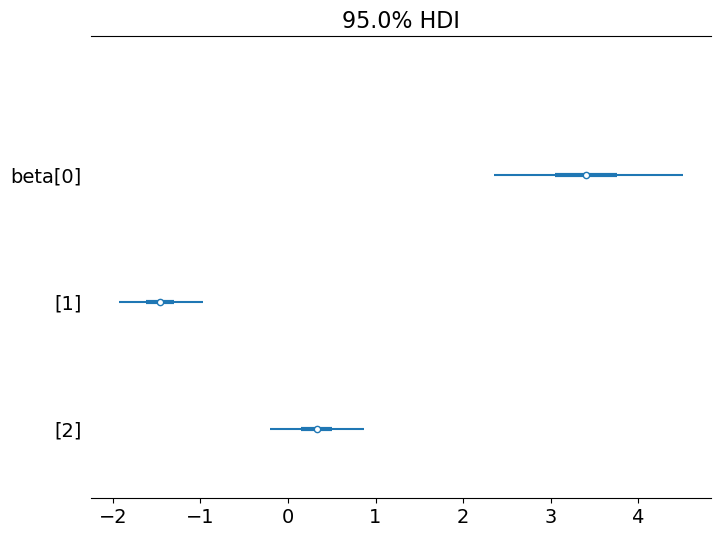

In [9]:
# Forest plot
az.plot_forest(
    trace_2,
    var_names=["beta"],
    combined=True,
    hdi_prob=0.95,
    figsize=(8, 6),
)


array([[<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

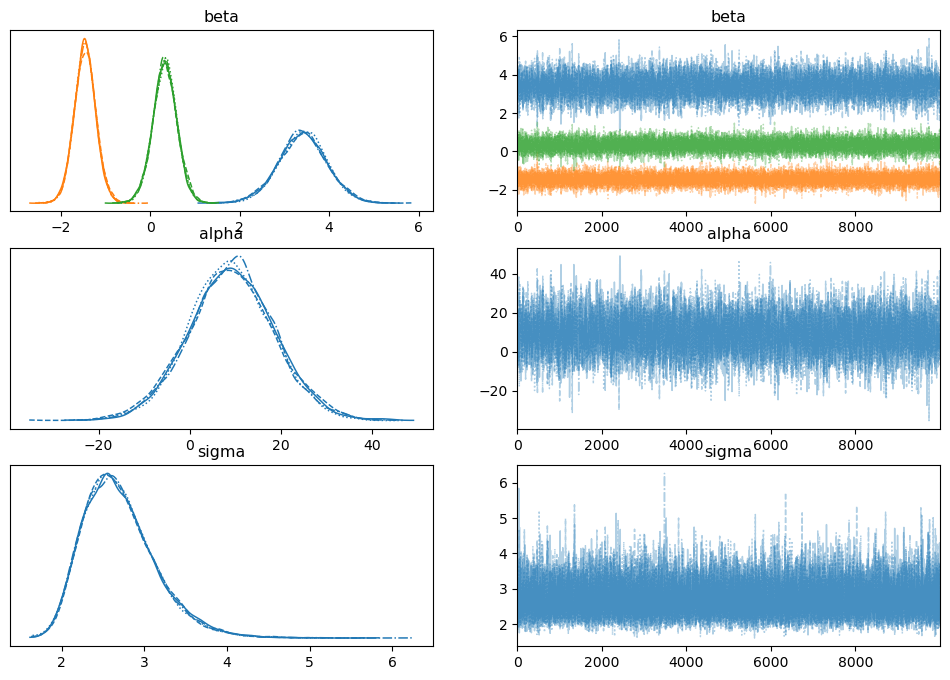

In [10]:
# plot trace
az.plot_trace(trace_2, var_names=["beta", "alpha", "sigma"], figsize=(12, 8))

Sampling: [likelihood]


Output()

Text(0.5, 1.0, 'Posterior Predictive Check - Cumulative Distribution of Predicted vs Observed')

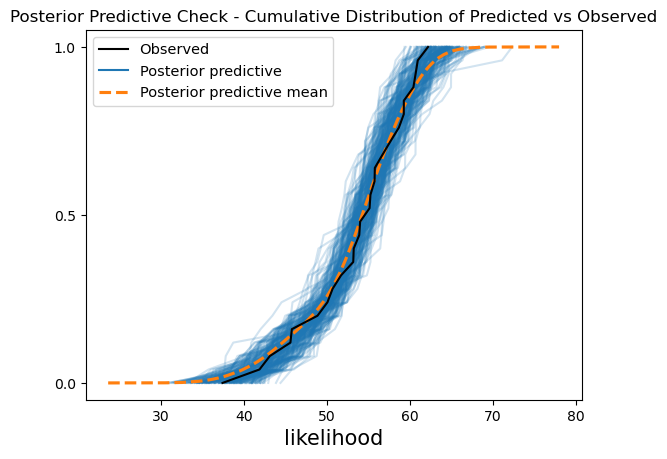

In [17]:
ppc_2 = pm.sample_posterior_predictive(
    trace_2, model=model_2, random_seed=rng, var_names=["likelihood"], extend_inferencedata=True   
    )
az.plot_ppc(ppc_2, kind="cumulative", num_pp_samples=200)
plt.title("Posterior Predictive Check - Cumulative Distribution of Predicted vs Observed")

In [18]:
# Calculate R-squared
ppc_2 = pm.sample_posterior_predictive(
    trace_2, model=model_2, random_seed=rng, var_names=["likelihood"], extend_inferencedata=True   
    )
y_pred = ppc_2.posterior_predictive.stack(sample=["chain", "draw"])['likelihood'].values.T
az.r2_score(y, y_pred)

Sampling: [likelihood]


Output()

r2        0.757599
r2_std    0.062557
dtype: float64

#### 2b) Finding outliers

In [19]:
def evaluate_ecdf(trace: az.InferenceData) -> np.array:
    """Evaluates ECDF at original observed values.

    This function assumes a single set of observed values.

    Args:
        trace: arviz.InferenceData from running a PyMC model.

    Returns:
        A Numpy array of the ECDF evaluation at each original datapoint.
    """
    # get posterior predictive variable name
    ppc_vars = list(trace.posterior_predictive.data_vars)
    assert (
        len(ppc_vars) == 1
    ), "Number of variables in posterior predictive must equal 1."
    y_varname = ppc_vars[0]

    # get original observations
    y_obs = trace.observed_data[y_varname].values
    assert (
        len(y_obs.shape) == 1
    ), "Y-observations shape must be one-dimensional."
    n_obs = y_obs.shape[0]
    y_obs = y_obs.reshape(-1, 1)  # for broadcasting

    # get posterior predictive samples for each y_obs and sample count
    y_samples_per_obs = trace.posterior_predictive[y_varname].stack(
        sample=("chain", "draw")
    )
    assert y_samples_per_obs.shape[0] == n_obs, "Shape assumptions aren't met."
    n_samples = y_samples_per_obs.shape[1]

    # evaluate ECDF at each y_obs and convert to numpy array
    ecdf_values = y_samples_per_obs <= y_obs
    prob = ecdf_values.sum(dim="sample") / n_samples

    return prob.to_numpy()

In [20]:
prob_ecdf_pit = evaluate_ecdf(trace_2)
loo_pit_output = az.loo_pit(trace_2, y="likelihood")
df_results = pd.DataFrame(
    {"likelihood": y, "loo_pit": loo_pit_output, "ecdf_pit": prob_ecdf_pit}
)
df_results["squared_logit"] = np.log(prob_ecdf_pit / (1 - prob_ecdf_pit)) ** 2

df_display = df_results.sort_values(by="squared_logit", ascending=False)
df_display.head()

,likelihood,loo_pit,ecdf_pit,squared_logit
14,53.254,0.000182,0.004975,28.072433
17,50.086,0.012956,0.033850,11.231749
16,58.699,0.954603,0.940400,7.610148
1,59.295,0.810913,0.790475,1.763029
19,62.213,0.791031,0.767325,1.423888


Text(0.5, 1.0, 'Posterior Predictive Check: Observed vs Predicted Values')

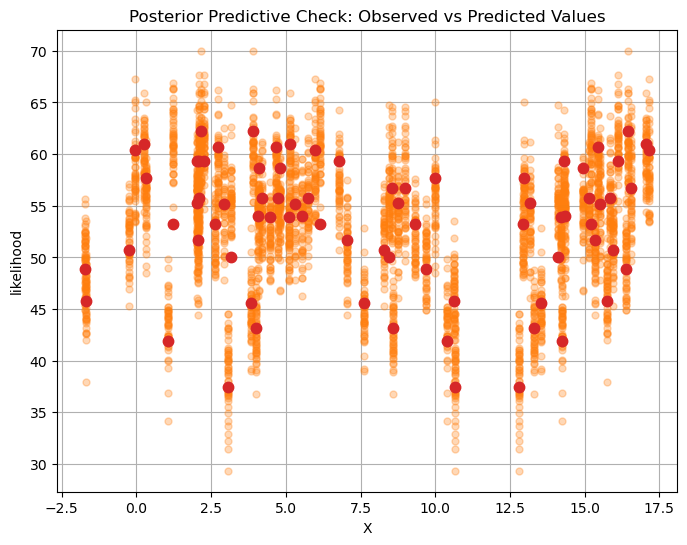

In [22]:
az.plot_lm(
    idata=trace_2,
    y="likelihood",
    x="X",
    figsize=(8, 6),
    legend=False,
)
plt.title("Posterior Predictive Check: Observed vs Predicted Values")


#### 2c) Two Robust Models built, one where $\nu$ is an exponential (less informative) and one where $\nu$ is a gamma distribution (more informative, favoring heavier tails)

In [23]:
# Build a more robust model by adding a Student's t likelihood
with pm.Model() as model_2_robust_v1:
    X_data = pm.Data("X_shared", X)
    y_data = pm.Data("y_shared", y)

    alpha = pm.Normal("alpha", mu=0, sigma=1000)
    beta = pm.Normal("beta", mu=0, sigma=1000, shape=X.shape[1])
    sigma = pm.Exponential("sigma", 0.001)
    nu = pm.Exponential("nu", 1/30)

    mu = pm.Deterministic("mu", alpha + pm.math.dot(X_data, beta))
    likelihood = pm.StudentT("likelihood", mu=mu, sigma=sigma, nu=nu, observed=y_data)

    # Prediction for new observation
    X_new = pm.Data("X_new", np.array([[10, 5, 4]]))
    mr = pm.Deterministic("mu_response", pm.math.dot(X_new, beta))
    pm.StudentT("predictive_response", mu=mr, sigma=sigma, nu=nu, observed=None)
    
    # Sampling
    trace_2_robust_v1 = pm.sample(10000, tune=2000, nuts_sampler="nutpie", random_seed=rng, target_accept=0.95)
    ppc_2_robust_v1 = pm.sample_posterior_predictive(
        trace_2_robust_v1, random_seed=rng, extend_inferencedata=True
    )
    pm.compute_log_likelihood(trace_2_robust_v1)

az.summary(trace_2_robust_v1, var_names=["alpha", "beta", "sigma", "nu"], round_to=3, hdi_prob=0.95)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,12000,0,0.09,95
,12000,0,0.07,127
,12000,0,0.06,63
,12000,0,0.06,15


Sampling: [likelihood]


Output()

Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,9.353,6.724,-2.608,23.702,0.133,0.259,3802.157,2712.109,1.001
beta[0],3.509,0.349,2.729,4.105,0.007,0.013,3838.349,2699.592,1.001
beta[1],-1.705,0.167,-2.072,-1.413,0.003,0.006,4765.660,2851.726,1.000
beta[2],0.360,0.214,-0.124,0.720,0.004,0.008,4411.129,2782.983,1.001
sigma,0.629,0.252,0.224,1.102,0.002,0.005,12890.137,16236.289,1.000
nu,1.434,1.404,0.476,2.620,0.018,0.278,10711.669,13768.332,1.001


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'nu'}>, <Axes: title={'center': 'nu'}>]],
      dtype=object)

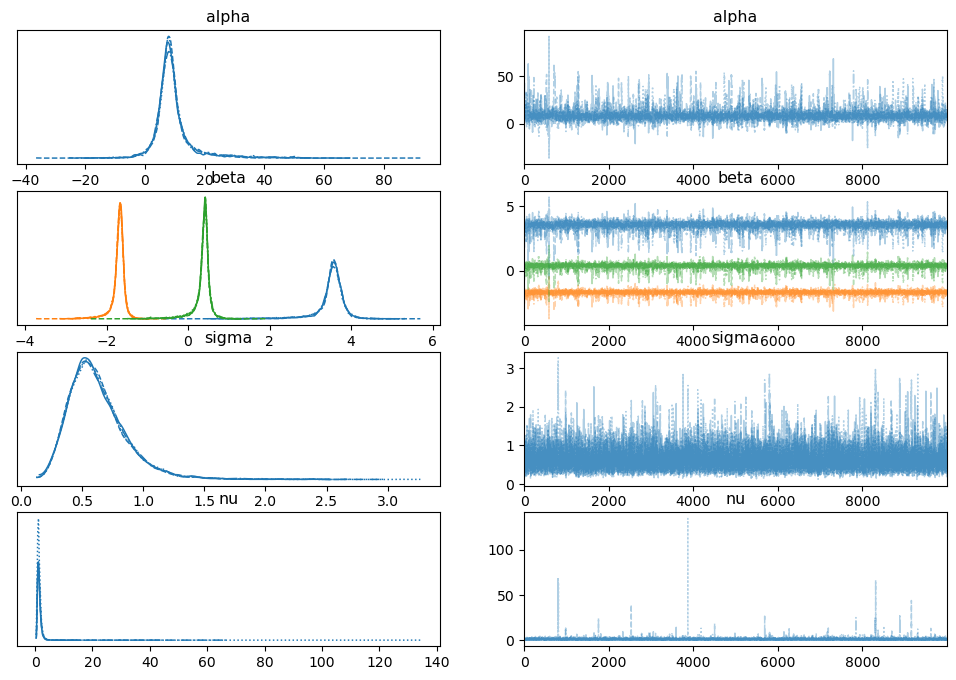

In [24]:
# plot trace for robust model
az.plot_trace(trace_2_robust_v1, var_names=["alpha", "beta", "sigma", "nu"])

In [25]:
# Same model but adjust prior on nu to be more informative and a different distribution
with pm.Model() as model_2_robust_v2:
    X_data = pm.Data("X_shared", X)
    y_data = pm.Data("y_shared", y)

    alpha = pm.Normal("alpha", mu=0, sigma=1000)
    beta = pm.Normal("beta", mu=0, sigma=1000, shape=X.shape[1])
    sigma = pm.Exponential("sigma", 0.001)
    nu = pm.Gamma("nu", alpha=3, beta=0.1)

    mu = pm.Deterministic("mu", alpha + pm.math.dot(X_data, beta))
    likelihood = pm.StudentT("likelihood", mu=mu, sigma=sigma, nu=nu, observed=y_data)

    # Prediction for new observation
    X_new = pm.Data("X_new", np.array([[10, 5, 4]]))
    mr = pm.Deterministic("mu_response", pm.math.dot(X_new, beta))
    pm.StudentT("predictive_response", mu=mr, sigma=sigma, nu=nu, observed=None)
    
    # Sampling
    trace_2_robust_v2 = pm.sample(10000, tune=2000, nuts_sampler="nutpie", random_seed=rng, target_accept=0.95)
    ppc_2_robust_v2 = pm.sample_posterior_predictive(
        trace_2_robust_v2, random_seed=rng, extend_inferencedata=True
    )
    pm.compute_log_likelihood(trace_2_robust_v2)

az.summary(trace_2_robust_v2, var_names=["alpha", "beta", "sigma", "nu"], round_to=3, hdi_prob=0.95)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,12000,0,0.11,63
,12000,0,0.09,63
,12000,0,0.10,127
,12000,0,0.11,31


Sampling: [likelihood]


Output()

Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,8.914,7.015,-3.981,24.622,0.141,0.322,3844.179,2285.246,1.001
beta[0],3.526,0.371,2.714,4.227,0.007,0.016,3875.509,2361.377,1.001
beta[1],-1.682,0.182,-2.063,-1.294,0.003,0.007,5190.224,2569.928,1.001
beta[2],0.367,0.220,-0.089,0.795,0.004,0.011,4588.115,2492.574,1.001
sigma,0.888,0.526,0.248,2.163,0.008,0.009,6876.473,6805.419,1.001
nu,3.694,7.206,0.434,14.495,0.090,0.208,8071.073,6462.489,1.000


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'nu'}>, <Axes: title={'center': 'nu'}>]],
      dtype=object)

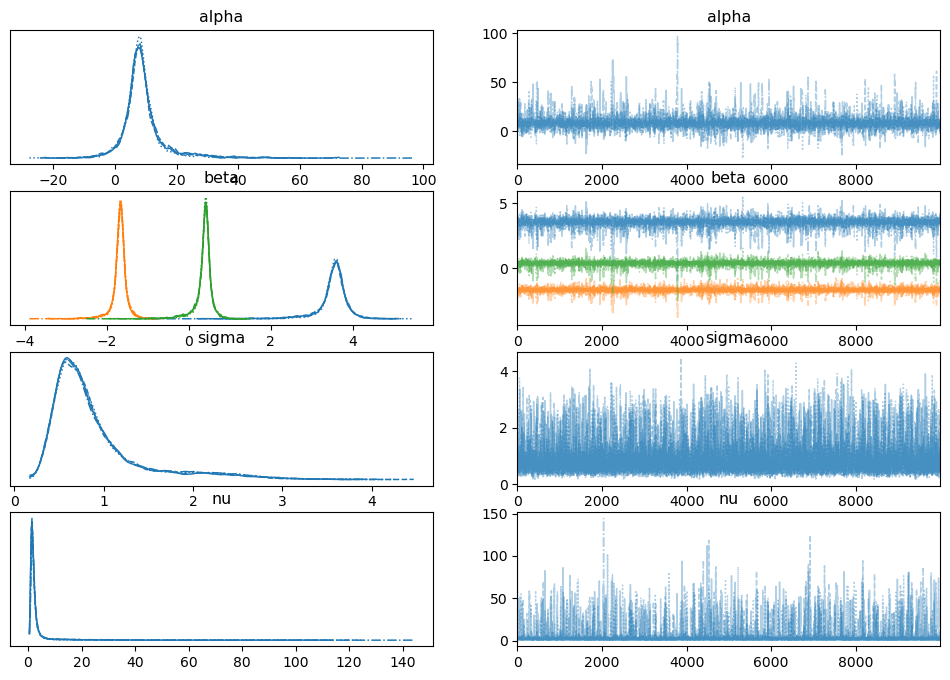

In [26]:
# Plot trace
az.plot_trace(trace_2_robust_v2, var_names=["alpha", "beta", "sigma", "nu"])

In [27]:
# Use PSIS-LOO to compare the original model with the two robust versions
loo_original = az.loo(trace_2, pointwise=True)
loo_robust_v1 = az.loo(trace_2_robust_v1, pointwise=True)
loo_robust_v2 = az.loo(trace_2_robust_v2, pointwise=True)
loo_comparison = az.compare(
    {"Original": trace_2, "Robust_v1": trace_2_robust_v1, "Robust_v2": trace_2_robust_v2},
)
loo_comparison

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Robust_v1,0,-51.936909,7.746752,0.000000,0.974857,8.549305,0.000000,False,log
Robust_v2,1,-55.284469,9.672960,3.347560,0.000000,9.044189,1.036810,False,log
Original,2,-65.928883,6.154757,13.991974,0.025143,6.940940,4.648625,True,log


#### 2d) Mean response at new data point

In [28]:
az.summary(ppc_2_robust_v1, var_names=["mu_response", "predictive_response"], round_to=3, hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_response[0],28.006,5.026,17.235,36.975,0.100,0.196,3811.497,2706.040,1.001
predictive_response[0],30.591,51.405,11.494,38.796,2.819,24.178,3412.826,2416.769,1.001


## Question 3

In [31]:
milling_data = pd.read_csv("data/millingmiss.csv")
milling_data.head()

,Hardness,Rake,Helix,Relief,Corner,Flute,force
0,0.000000,0.8326,0.461583,0.966667,0.1560,0.168333,542.4469
1,0.006133,0.5642,0.744583,0.725000,0.5614,0.561667,548.4845
2,0.015600,0.1916,0.206667,0.415500,0.4528,0.828333,NaN
3,0.022133,0.7510,0.321250,0.000000,0.8804,0.371667,601.0511
4,0.030567,0.0824,0.985500,0.540333,0.0372,0.418333,498.5836


In [32]:
y = milling_data["force"].to_numpy(copy=True)
X = milling_data.drop(columns=["force"]).to_numpy(copy=True)
feature_names = milling_data.drop(columns=["force"]).columns.values
# Check for missing values in X
print("Missing values in X:", np.isnan(X).sum())

Missing values in X: 0


In [33]:
chains = 4
draws = 10000
rows = chains * draws

In [34]:
# Assume MCAR missingness and fit a linear regression model
with pm.Model(coords={"feature": feature_names}) as model_milling_mcar:
    X_data = pm.Data("X", X)
    # Priors
    alpha = pm.Normal("alpha", mu=0, sigma=100)
    beta = pm.Normal("beta", mu=0, sigma=100, shape=X.shape[1], dims="feature")
    sigma = pm.Exponential("sigma", 0.001)
    mu = pm.Deterministic("mu", alpha + pm.math.dot(X_data, beta))
    
    likelihood = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=y)

    trace_milling_mcar = pm.sample(draws, tune=2000, chains=chains, nuts_sampler="nutpie", random_seed=rng, target_accept=0.95)
    ppc_mcar = pm.sample_posterior_predictive(trace_milling_mcar, extend_inferencedata=True)

az.summary(trace_milling_mcar, var_names=["alpha", "beta", "sigma"], round_to=3, hdi_prob=0.95)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,12000,0,0.23,79
,12000,0,0.20,31
,12000,0,0.21,31
,12000,0,0.21,15


Sampling: [likelihood_observed]


Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,614.227,11.003,592.493,635.825,0.109,0.076,10245.674,14981.858,1.0
beta[Hardness],60.436,9.198,42.326,78.550,0.074,0.049,15471.280,22104.508,1.0
beta[Rake],-4.015,8.680,-21.219,13.138,0.058,0.048,21977.459,25059.747,1.0
beta[Helix],-158.225,9.734,-177.262,-138.871,0.078,0.052,15733.428,21850.665,1.0
beta[Relief],-9.598,8.628,-26.654,7.123,0.062,0.046,19525.553,24914.963,1.0
beta[Corner],-4.684,8.509,-21.972,11.468,0.061,0.045,19443.980,23501.756,1.0
beta[Flute],84.449,9.525,65.980,103.477,0.067,0.052,19855.594,24087.984,1.0
sigma,17.991,2.197,14.016,22.386,0.016,0.012,19001.391,24724.425,1.0


#### 3b) Fit MNAR model

In [36]:
# Mask y nan values
y_masked = np.ma.masked_invalid(y)
# Change nan values to -1
y_masked = np.ma.masked_values(y_masked, value=-1)
miss = y_masked.mask
miss

array([False, False,  True, False, False, False,  True, False,  True,
       False, False, False, False, False,  True,  True, False, False,
       False, False, False,  True, False, False, False,  True, False,
       False, False,  True, False, False,  True, False, False, False,
        True, False,  True, False, False, False, False, False,  True,
        True, False, False, False, False, False,  True, False, False,
       False,  True, False, False, False,  True])

In [37]:
# Assume MNAR for the same model
b = 0.1 # log odds increase of missingness by 0.1 for every 1 unit increase in y

with pm.Model(coords={"feature": feature_names}) as model_milling_mnar:
    X_data = pm.Data("X", X)
    # Priors
    alpha = pm.Normal("alpha", mu=0, sigma=100)
    beta = pm.Normal("beta", mu=0, sigma=100, shape=X.shape[1], dims="feature")
    sigma = pm.Exponential("sigma", 0.001)                        
    mu = pm.Deterministic("mu", alpha + pm.math.dot(X, beta))

    y_imputed = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=y_masked)

    # Missingness model
    p = pm.Deterministic("p", pm.math.invlogit(b * (y_imputed - 650)))
    pm.Bernoulli("missingness", p=p, observed=miss)

    trace_milling_mnar = pm.sample(10000, tune=4000, nuts_sampler="nutpie", target_accept=0.95, random_seed=rng)
    ppc_mnar = pm.sample_posterior_predictive(trace_milling_mnar, extend_inferencedata=True)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,14000,0,0.22,15
,14000,0,0.20,15
,14000,0,0.22,31
,14000,0,0.20,15


Sampling: [likelihood_observed, missingness]


Output()

In [39]:
az.summary(trace_milling_mnar, var_names=["alpha", "beta", "sigma"], round_to=3, hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,602.388,18.233,566.781,638.451,0.180,0.118,10225.765,15534.653,1.0
beta[Hardness],82.207,14.270,54.610,110.389,0.110,0.076,16986.657,21729.978,1.0
beta[Rake],-14.778,13.968,-42.061,12.971,0.089,0.075,24322.720,25754.844,1.0
beta[Helix],-146.605,14.736,-175.478,-117.302,0.106,0.081,19380.400,24982.281,1.0
beta[Relief],3.915,14.383,-24.507,32.196,0.105,0.080,19078.796,22356.350,1.0
beta[Corner],7.962,14.135,-20.117,35.809,0.101,0.082,19756.280,21957.400,1.0
beta[Flute],80.331,14.557,51.957,109.538,0.093,0.079,24388.843,23669.927,1.0
sigma,31.832,5.403,21.943,42.947,0.054,0.033,9745.528,14692.332,1.0


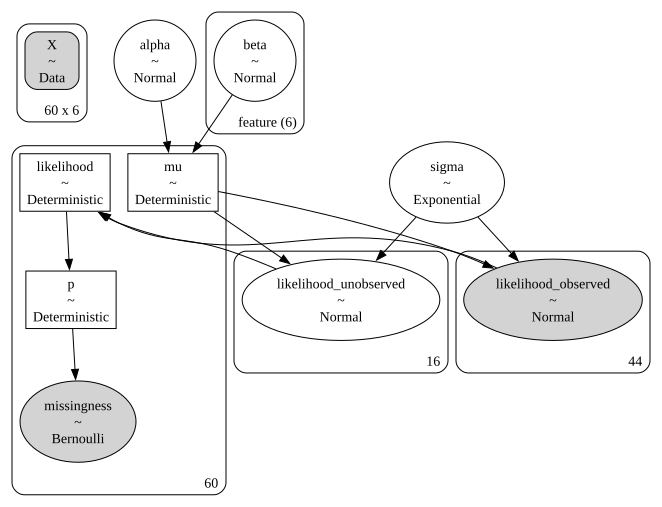

In [40]:
pm.model_to_graphviz(model_milling_mnar)

#### 3c)

In [41]:
# Find values that minimise posterior mean based on whether beta coefficients are positive or negative
beta_means = trace_milling_mnar.posterior["beta"].mean(dim=["chain", "draw"]).values
print("Posterior mean of beta coefficients:", beta_means)

X_min = np.where(beta_means > 0, X.min(axis=0), X.max(axis=0))
print("X values corresponding to minimum posterior mean based on beta coefficients:")
for i, feature in enumerate(milling_data.drop(columns=["force"]).columns):
    print(f"{feature}: {round(X_min[i], 3)}")



Posterior mean of beta coefficients: [  82.20661621  -14.77848212 -146.60528458    3.91549271    7.9617243
   80.33107962]
X values corresponding to minimum posterior mean based on beta coefficients:
Hardness: 0.0
Rake: 1.0
Helix: 1.0
Relief: 0.0
Corner: 0.0
Flute: 0.0


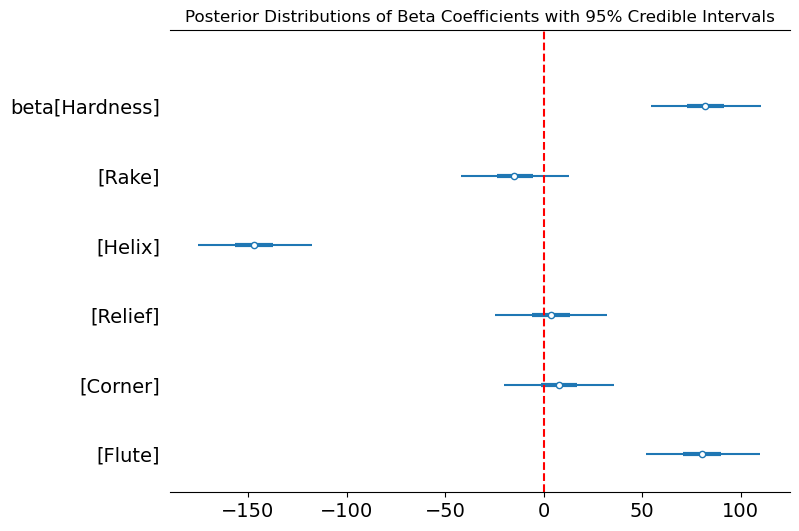

In [42]:
# Plot beta forest plot
az.plot_forest(
    trace_milling_mnar,
    var_names=["beta"],
    combined=True,
    hdi_prob=0.95,
    figsize=(8, 6),
)
plt.title("Posterior Distributions of Beta Coefficients with 95% Credible Intervals")
plt.axvline(0, color="red", linestyle="--")

In [44]:
with pm.Model(coords={"id": [0], "feature": feature_names}) as model_milling_mnar_pred:
    alpha = pm.Normal("alpha", mu=0, sigma=100)
    beta = pm.Normal("beta", mu=0, sigma=100, shape=X.shape[1])
    sigma = pm.Exponential("sigma", 0.001)                        

    # Prediction for minimum X values
    mu_new = pm.Deterministic("mu_new", alpha + pm.math.dot(X_min, beta))
    pm.Normal("likelihood", mu=mu_new, sigma=sigma, dims="id")

    ppc_mnar_pred = pm.sample_posterior_predictive(trace_milling_mnar, var_names=["likelihood"], predictions=True)

az.summary(ppc_mnar_pred, var_names=["likelihood"], round_to=3, hdi_prob=0.95)

Sampling: [likelihood]


Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
likelihood[0],441.217,37.09,364.807,511.914,0.206,0.161,32607.886,33208.798,1.0
